# Self-Attention from Scratch — Movie Reviews (SOLUTION)

This lesson builds the core of the Transformer — **self-attention** — from scratch,
before wrapping it inside a full Transformer in Lesson 07.

We reuse the NLTK `movie_reviews` dataset from Lesson 03 (CNN) so you can
directly compare accuracy.  By the end you will have:
- Implemented scaled dot-product attention as a `nn.Module`
- Implemented multi-head self-attention from those building blocks
- Trained a simple attention-based classifier and visualised what it attends to

## Key Concept: Why Attention?

Lessons 03–05 built two families of models for sequences:

| Model | How it handles a sequence | Limitation |
|---|---|---|
| **CNN** (Lesson 03) | Fixed-width kernels scan left-to-right | Can only detect patterns up to `kernel_size` tokens wide |
| **RNN / LSTM** (Lessons 04–05) | Hidden state carries context from left | Long-range info must survive 100+ sequential multiplications → degrades |

**Self-attention** solves both at once.  At every position, the model can look
directly at *every other position in the same sequence* — in one parallel operation,
with no fixed kernel size and no sequential bottleneck.

**The key question** self-attention answers at each position:
> "Which other tokens in this sequence are most relevant to understanding *me*?"

The answer is a learned, input-dependent weighted average of all positions.
Unlike CNN kernels (fixed after training) or RNN weights (input-independent),
the attention weights change for every new input sentence.

## Step 1: Imports

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import nltk
import random
from collections import Counter
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: mps


## Key Concept: Devices and `.to(device)`

PyTorch can run computations on the **CPU** or a **GPU** (NVIDIA CUDA or Apple MPS).
Moving a tensor or model to a device with `.to(device)` is a one-time copy — after that,
all operations on that object stay on the same device.

```python
device = torch.device('mps' if torch.backends.mps.is_available() else
                      'cuda' if torch.cuda.is_available() else 'cpu')

model = MyModel().to(device)   # move all parameters to the device once
Xb, yb = Xb.to(device), yb.to(device)   # move each batch in the training loop
```

On this machine, `device` will be `mps` (Apple GPU), `cuda` (NVIDIA GPU), or `cpu`.

## Key Concept: `Dataset` and `DataLoader`

`DataLoader` handles batching, shuffling, and parallel data loading so your
training loop never touches individual examples.

```python
from torch.utils.data import TensorDataset, DataLoader

dataset = TensorDataset(X_tensor, y_tensor)   # pairs up inputs with labels
loader  = DataLoader(dataset, batch_size=32, shuffle=True)

for Xb, yb in loader:   # Xb: (32, 200), yb: (32,)
    ...
```

`shuffle=True` re-orders the data every epoch — essential to avoid the model
memorising the order rather than the content.

## Step 2: Load Movie Reviews (same as Lesson 03)

Same dataset, same preprocessing — 2 000 reviews, 1 600 train / 400 test,
vocabulary capped at 10 000 words, reviews padded/truncated to 200 tokens.

In [2]:
nltk.download('movie_reviews', quiet=True)
from nltk.corpus import movie_reviews

random.seed(42)
docs = [(movie_reviews.words(fid), cat)
        for cat in movie_reviews.categories()
        for fid in movie_reviews.fileids(cat)]
random.shuffle(docs)
print(f'Total reviews : {len(docs)}')
print(f'Sample words  : {list(docs[0][0])[:10]}')
print(f'Label         : {docs[0][1]}')

Total reviews : 2000
Sample words  : ['mr', '.', 'bean', ',', 'a', 'bumbling', 'security', 'guard', 'from', 'england']
Label         : neg


## Step 3: Build Vocabulary and Encode Reviews

In [3]:
MAX_VOCAB = 10_000   # cap vocabulary; tail words are rare and add noise
MAX_LEN   = 200      # truncate/pad all reviews to this length

all_words = [w.lower() for ws, _ in docs for w in ws]
freq      = Counter(all_words)
# Index 0 = <PAD>: padding_idx=0 zeroes this embedding vector (no signal)
# Index 1 = <UNK>: any out-of-vocabulary word maps here
vocab = {'<PAD>': 0, '<UNK>': 1}
for w, _ in freq.most_common(MAX_VOCAB - 2):
    vocab[w] = len(vocab)
print(f'Vocabulary size: {len(vocab)}')

def encode(words, vocab, max_len):
    tokens = [vocab.get(w.lower(), 1) for w in words][:max_len]
    tokens += [0] * (max_len - len(tokens))
    return tokens

X_data = [encode(ws, vocab, MAX_LEN) for ws, _ in docs]
y_data = [1 if label == 'pos' else 0 for _, label in docs]

X_tensor = torch.tensor(X_data, dtype=torch.long)
y_tensor  = torch.tensor(y_data, dtype=torch.float)
print(f'X shape: {X_tensor.shape}   y shape: {y_tensor.shape}')

Vocabulary size: 10000


X shape: torch.Size([2000, 200])   y shape: torch.Size([2000])


## Step 4: DataLoaders

In [4]:
split = int(0.8 * len(X_tensor))   # 1 600 train / 400 test
X_train, X_test = X_tensor[:split], X_tensor[split:]
y_train, y_test = y_tensor[:split], y_tensor[split:]

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=32, shuffle=True)
test_loader  = DataLoader(TensorDataset(X_test,  y_test),  batch_size=32)
print(f'Train batches: {len(train_loader)}   Test batches: {len(test_loader)}')

Train batches: 50   Test batches: 13


## Key Concept: Scaled Dot-Product Attention

Given an input sequence `X` of shape `(batch_size, seq_len, d_model)`,
self-attention projects it into three roles and then computes a weighted average:

```
Q = X · W_Q    ← "What am I looking for?"        shape (B, L, d_k)
K = X · W_K    ← "What do I offer to others?"    shape (B, L, d_k)
V = X · W_V    ← "What information do I carry?"  shape (B, L, d_k)
```

All three come from the **same** input `X`; the three weight matrices `W_Q`,
`W_K`, `W_V` are learned.  This is called *self*-attention because keys, queries,
and values all originate from the same sequence.

**The formula:**
```
Attention(Q, K, V) = softmax( Q Kᵀ / √d_k ) · V
```

Step by step:
1. `Q Kᵀ` — shape `(B, L, L)` — score how well each query matches each key
2. `/ √d_k` — scale to prevent softmax saturation (variance of dot products grows with d_k)
3. `softmax(·)` — turn scores into attention weights; each row sums to 1
4. `· V` — weighted average of value vectors — shape `(B, L, d_k)`

`weights[b, i, j]` = how much position `i` attends to position `j` in sequence `b`.

## Step 5: Scaled Dot-Product Attention

Implements `Attention(Q, K, V) = softmax(Q Kᵀ / √d_k) · V`.
Returns both the attended output **and** the attention weight matrix
(we need the weights later to visualise what each position attends to).

In [5]:
class ScaledDotProductAttention(nn.Module):
    """Attention(Q,K,V) = softmax(QKᵀ/√d_k) · V"""

    def __init__(self, d_k: int, dropout: float = 0.1):
        super().__init__()
        # Precompute the scale factor: dividing by √d_k keeps the dot-product
        # variance near 1 regardless of how large d_k is.
        self.scale   = d_k ** -0.5
        self.dropout = nn.Dropout(dropout)

    def forward(self, Q, K, V):
        # Q, K, V shape: (batch_size, num_heads, seq_len, d_k)
        # Step 1: raw alignment scores — how well does each query match each key?
        scores  = torch.matmul(Q, K.transpose(-2, -1)) * self.scale  # (B, H, L, L)
        # Step 2: softmax over the last dim — each row of weights sums to 1
        weights = self.dropout(torch.softmax(scores, dim=-1))         # (B, H, L, L)
        # Step 3: weighted average of value vectors
        out     = torch.matmul(weights, V)                            # (B, H, L, d_k)
        return out, weights

### Concept Check: Scaled Dot-Product Attention

**Q1.** The score matrix has shape `(B, H, L, L)`.
What does entry `[b, h, i, j]` represent?
What does a large positive value mean?

**Q2.** Why divide by `√d_k` instead of, say, `d_k` or nothing at all?
What goes wrong if you skip the scaling on large `d_k` values?

**Q3.** After softmax, the attention weight matrix has rows that each sum to 1.
What does this mean for the output at position `i` when `weights[b, h, i, :]`
is `[0, 0, 1, 0, …]` vs `[1/L, 1/L, …, 1/L]`?

### Concept Check: Scaled Dot-Product Attention — Answers

**Q1.** `[b, h, i, j]` is the (post-softmax) attention weight for position `i`
attending to position `j` in head `h` of sequence `b`.
A large positive *pre*-softmax score means position `i` finds position `j`
highly relevant — after softmax, position `j` will receive a large fraction
of position `i`'s attention.

**Q2.** The dot product `Q·K` has variance proportional to `d_k`
(the inner-product of two random d_k-dimensional vectors sums d_k independent
terms). Without scaling, large `d_k` pushes scores into extreme regions where
`softmax′(x) → 0` — gradients through the attention weights vanish.
Dividing by `√d_k` normalises the variance back to ≈ 1 regardless of dimension.
Dividing by `d_k` (not `√d_k`) would over-correct and shrink scores too much.

**Q3.**
- `[0, 0, 1, 0, …]` — position `i` attends *entirely* to position 2;
  the output at `i` is exactly the value vector of position 2.
- `[1/L, …, 1/L]` — uniform attention; the output is the simple average
  of *all* value vectors — the attention mechanism contributes nothing
  beyond mean pooling.

## Key Concept: Multi-Head Attention

A single attention function captures one type of relationship.
**Multi-head attention** runs `H` independent attention functions in parallel,
each with its own `W_Q`, `W_K`, `W_V` projections, then concatenates their outputs.

```
head_h = Attention(X·W_Qh, X·W_Kh, X·W_Vh)   shape (B, L, d_k)  where d_k = d_model / H
output  = Concat(head_1 … head_H) · W_O        shape (B, L, d_model)
```

**Why H heads?**  Different heads can specialise independently:
- One head might capture *semantic similarity* ("film" ↔ "movie")
- Another might capture *negation* ("not" ↔ the word it modifies)
- Another might track *syntactic roles* (subject ↔ verb)
The model learns what to look for — you don't specify it.

**Implementation trick:** rather than H separate attention calls, we reshape the
projection matrices so all heads run as one batched matrix multiplication:
```
(B, L, d_model)  →  reshape  →  (B, L, H, d_k)  →  transpose  →  (B, H, L, d_k)
```
This is more efficient on GPU but mathematically identical.

## Step 6: Multi-Head Self-Attention

Wraps `ScaledDotProductAttention` into `H` parallel heads.

Key shapes:
```
input x              (B, L, d_model)
after W_Q/W_K/W_V    (B, L, d_model)
split into H heads   (B, H, L, d_k)     d_k = d_model / H
attention output     (B, H, L, d_k)
merge heads          (B, L, d_model)
after W_O            (B, L, d_model)
```

In [6]:
class MultiHeadSelfAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1):
        super().__init__()
        assert d_model % num_heads == 0, 'd_model must be divisible by num_heads'
        self.H   = num_heads
        self.d_k = d_model // num_heads

        # One linear projection per role.  All heads share these matrices —
        # the head split happens by reshaping, not by separate parameters.
        self.W_q = nn.Linear(d_model, d_model)
        self.W_k = nn.Linear(d_model, d_model)
        self.W_v = nn.Linear(d_model, d_model)
        self.W_o = nn.Linear(d_model, d_model)  # mixes information across heads

        self.attn    = ScaledDotProductAttention(self.d_k, dropout)
        self.dropout = nn.Dropout(dropout)

    def split_heads(self, x):
        # x: (B, L, d_model) → (B, H, L, d_k)
        # Reshape last dim into (H, d_k) then move the head axis forward
        B, L, _ = x.shape
        return x.view(B, L, self.H, self.d_k).transpose(1, 2)

    def merge_heads(self, x):
        # x: (B, H, L, d_k) → (B, L, d_model)
        # .contiguous() is required before .view() after .transpose()
        # because transpose returns a non-contiguous view and view needs
        # contiguous memory to rearrange elements correctly
        B, H, L, d_k = x.shape
        return x.transpose(1, 2).contiguous().view(B, L, H * d_k)

    def forward(self, x):
        # Project input into queries, keys, values and split across heads
        Q = self.split_heads(self.W_q(x))   # (B, H, L, d_k)
        K = self.split_heads(self.W_k(x))
        V = self.split_heads(self.W_v(x))

        # Run scaled dot-product attention across all heads simultaneously
        attended, weights = self.attn(Q, K, V)   # (B, H, L, d_k), (B, H, L, L)

        # Reassemble heads and project to output space
        out = self.W_o(self.merge_heads(attended))   # (B, L, d_model)
        return out, weights

### Concept Check: Multi-Head Attention

**Q1.** With `d_model=64` and `num_heads=4`, each head operates in `d_k=16`
dimensions. How many learnable parameters does `W_q` have?
If you doubled `num_heads` to 8, how many parameters would `W_q` have?

**Q2.** `split_heads` calls `.view(B, L, H, d_k).transpose(1, 2)`.
Why is `.contiguous()` needed in `merge_heads` before calling `.view`?

**Q3.** What would happen if you removed `W_o` (the output projection)
and returned the concatenated head outputs directly?
Why is `W_o` important?

### Concept Check: Multi-Head Attention — Answers

**Q1.** `W_q` maps `(d_model, d_model) = (64, 64)` — **4 096 parameters**,
regardless of `num_heads`.  Increasing `num_heads` from 4 to 8 does not
change the parameter count: each head gets a smaller slice (`d_k = 8`)
of the same total projection.

**Q2.** `.transpose()` returns a *view* with non-contiguous memory — the
elements are still in the original layout, just addressed differently.
`.view()` requires contiguous memory (it reads elements in row-major order).
`.contiguous()` creates a new tensor with the right memory layout before
`.view()` restructures the dimensions.

**Q3.** Without `W_o`, the concatenated head outputs are used directly.
`W_o` learns how to *mix* information across heads — each output position
can draw on patterns detected by all `H` heads simultaneously.
Without it, the heads remain independent and cannot share what they found.

## Step 7: Simple Attention Classifier

Deliberately minimal — no positional encoding, no feed-forward sublayer,
no layer normalisation.  Just:

```
Embedding → MultiHeadSelfAttention → mean pool → Linear → sigmoid
```

This isolates what self-attention alone can do.
Lesson 07 adds the remaining Transformer components.

In [7]:
class SimpleAttentionClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim=64, num_heads=4, dropout=0.3):
        super().__init__()
        self.embed = nn.Embedding(vocab_size, embed_dim, padding_idx=0)
        self.attn  = MultiHeadSelfAttention(embed_dim, num_heads, dropout)
        self.drop  = nn.Dropout(dropout)
        self.fc    = nn.Linear(embed_dim, 1)

    def forward(self, x):
        # x: (B, L) integer word indices
        emb             = self.drop(self.embed(x))   # (B, L, embed_dim)
        out, weights    = self.attn(emb)             # (B, L, embed_dim), (B, H, L, L)
        pooled          = out.mean(dim=1)            # (B, embed_dim) — average over positions
        logit           = self.fc(pooled).squeeze(-1) # (B,)
        return logit, weights

vocab_size = len(vocab)
model      = SimpleAttentionClassifier(vocab_size, embed_dim=64, num_heads=4).to(device)
print(model)
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')

SimpleAttentionClassifier(
  (embed): Embedding(10000, 64, padding_idx=0)
  (attn): MultiHeadSelfAttention(
    (W_q): Linear(in_features=64, out_features=64, bias=True)
    (W_k): Linear(in_features=64, out_features=64, bias=True)
    (W_v): Linear(in_features=64, out_features=64, bias=True)
    (W_o): Linear(in_features=64, out_features=64, bias=True)
    (attn): ScaledDotProductAttention(
      (dropout): Dropout(p=0.3, inplace=False)
    )
    (dropout): Dropout(p=0.3, inplace=False)
  )
  (drop): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=64, out_features=1, bias=True)
)
Trainable parameters: 656,705


## Key Concept: The Training Loop

The same loop pattern used throughout this curriculum.
`model.forward()` now returns two values — we unpack both and only use `logits`
for the loss.  The attention `weights` are discarded during training; we retrieve
them later for visualisation.

```python
logits, _weights = model(Xb)   # ignore weights during training
loss = criterion(logits, yb)
```

Each step:
1. `optimizer.zero_grad()` — clear accumulated gradients from the previous batch
2. `model(Xb)` — forward pass; PyTorch records every operation into a computational graph
3. `criterion(logits, yb)` — compare predictions to targets
4. `loss.backward()` — walk the graph backwards, computing `∂loss/∂param` for every parameter
5. `optimizer.step()` — apply the Adam update rule using those gradients
6. `loss.item()` — extract a plain Python float and release this batch's computation graph

## Step 8: Train

In [8]:
criterion = nn.BCEWithLogitsLoss()   # combines sigmoid + BCE; numerically stable
optimizer = optim.Adam(model.parameters(), lr=1e-3)

def train_one_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0.0
    for Xb, yb in loader:
        Xb, yb = Xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits, _ = model(Xb)   # weights discarded during training
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(Xb)
    return total_loss / len(loader.dataset)

epoch_losses = []
EPOCHS = 10
for epoch in range(1, EPOCHS + 1):
    loss = train_one_epoch(model, train_loader, criterion, optimizer)
    epoch_losses.append(loss)
    print(f'Epoch {epoch:2d}/{EPOCHS}  loss={loss:.4f}')

Epoch  1/10  loss=0.6919


Epoch  2/10  loss=0.6792


Epoch  3/10  loss=0.6480


Epoch  4/10  loss=0.5964


Epoch  5/10  loss=0.5450


Epoch  6/10  loss=0.4766


Epoch  7/10  loss=0.4191


Epoch  8/10  loss=0.3715


Epoch  9/10  loss=0.2916


Epoch 10/10  loss=0.2552


## Step 9: Evaluate

In [9]:
def evaluate(model, loader):
    model.eval()
    correct = total = 0
    with torch.no_grad():
        for Xb, yb in loader:
            Xb, yb = Xb.to(device), yb.to(device)
            logits, _ = model(Xb)
            preds = (torch.sigmoid(logits) >= 0.5).long()
            correct += (preds == yb.long()).sum().item()
            total   += len(yb)
    return correct / total

train_acc = evaluate(model, train_loader)
test_acc  = evaluate(model, test_loader)
print(f'Train accuracy: {train_acc:.1%}')
print(f'Test  accuracy: {test_acc:.1%}')
print()
print('Benchmark comparison:')
print(f'  CNN (Lesson 03) test accuracy: ~82%')
print(f'  Self-attention  (this model) : {test_acc:.1%}')
print(f'  Transformer (Lesson 07)      : ~85%  (adds positional enc + FFN layers)')

Train accuracy: 95.5%
Test  accuracy: 65.2%

Benchmark comparison:
  CNN (Lesson 03) test accuracy: ~82%
  Self-attention  (this model) : 65.2%
  Transformer (Lesson 07)      : ~85%  (adds positional enc + FFN layers)


## Step 10: Visualise Attention Weights

Pick a sample review from the test set and plot what each attention head
"looks at" for the first 20 tokens.

Each cell `[i, j]` in a head's heatmap shows how much token `i`
attends to token `j` — darker = stronger attention.

True label: pos   Predicted: pos


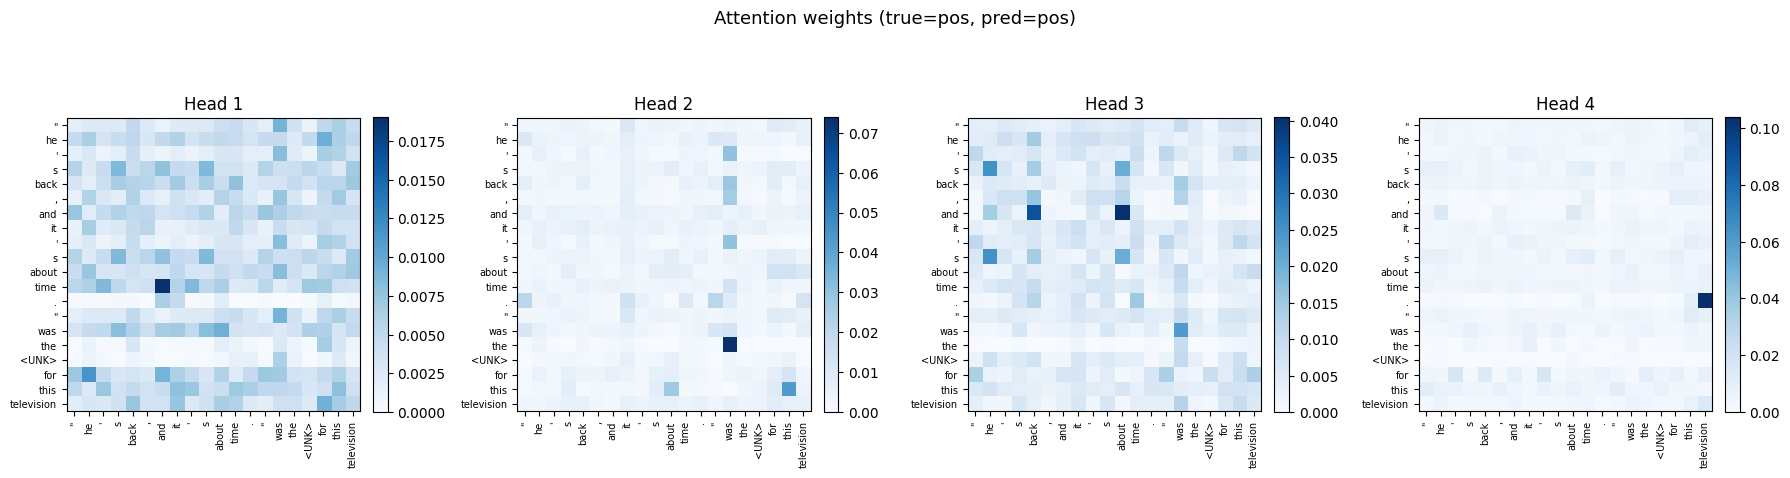

In [10]:
# Retrieve attention weights for one test sample
idx2word = {v: k for k, v in vocab.items()}

sample_X, sample_y = X_test[0:1].to(device), y_test[0]
model.eval()
with torch.no_grad():
    logit, weights = model(sample_X)

pred  = 'pos' if torch.sigmoid(logit).item() >= 0.5 else 'neg'
truth = 'pos' if sample_y.item() == 1 else 'neg'
print(f'True label: {truth}   Predicted: {pred}')

# Decode the first 20 tokens for axis labels
tokens = [idx2word.get(i.item(), '<UNK>') for i in sample_X[0, :20]]

# weights shape: (B=1, H=4, L=200, L=200) — take the first sample, first 20×20 block
W = weights[0, :, :20, :20].cpu().numpy()   # (H, 20, 20)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Attention weights (true={truth}, pred={pred})', fontsize=13)

for h, ax in enumerate(axes):
    im = ax.imshow(W[h], cmap='Blues', vmin=0, vmax=W[h].max())
    ax.set_xticks(range(20))
    ax.set_yticks(range(20))
    ax.set_xticklabels(tokens, rotation=90, fontsize=7)
    ax.set_yticklabels(tokens, fontsize=7)
    ax.set_title(f'Head {h+1}')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

## Step 11: Plot Training Loss

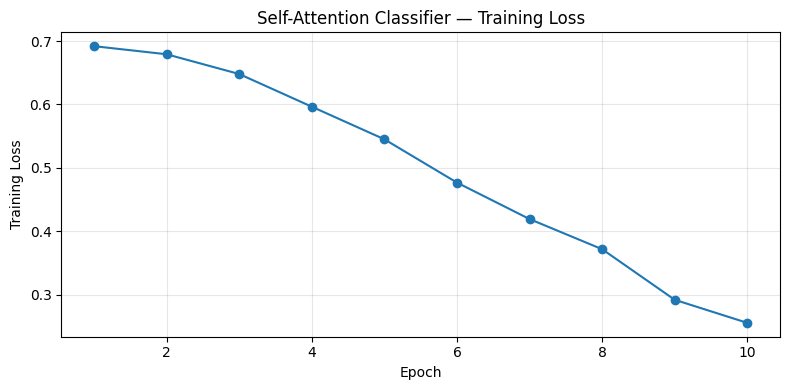

In [11]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(epoch_losses)+1), epoch_losses, marker='o')
plt.xlabel('Epoch')
plt.ylabel('Training Loss')
plt.title('Self-Attention Classifier — Training Loss')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Step 12: Visualise the Model Architecture

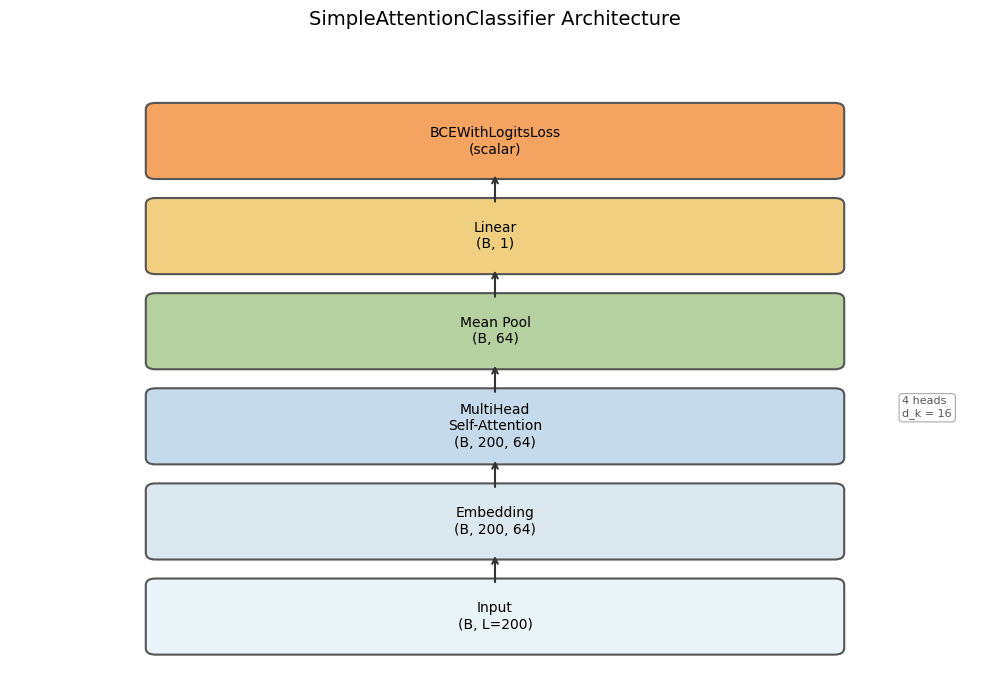

In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(10, 7))
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.axis('off')
ax.set_title('SimpleAttentionClassifier Architecture', fontsize=14, pad=15)

layers = [
    (0.5, 'Input\n(B, L=200)', '#e8f4f8'),
    (2.0, 'Embedding\n(B, 200, 64)', '#dce8f0'),
    (3.5, 'MultiHead\nSelf-Attention\n(B, 200, 64)', '#c5daea'),
    (5.0, 'Mean Pool\n(B, 64)', '#b5d1a0'),
    (6.5, 'Linear\n(B, 1)', '#f0d080'),
    (8.0, 'BCEWithLogitsLoss\n(scalar)', '#f4a460'),
]

for y, label, color in layers:
    ax.add_patch(mpatches.FancyBboxPatch((1.5, y), 7, 1.0,
        boxstyle='round,pad=0.1', facecolor=color, edgecolor='#555', linewidth=1.5))
    ax.text(5, y + 0.5, label, ha='center', va='center', fontsize=10)

for i in range(len(layers) - 1):
    y0 = layers[i][0] + 1.0
    y1 = layers[i+1][0]
    ax.annotate('', xy=(5, y1), xytext=(5, y0),
                arrowprops=dict(arrowstyle='->', color='#333', lw=1.5))

note_y = layers[2][0] + 0.1
ax.text(9.2, note_y + 0.7, '4 heads\nd_k = 16', ha='left', va='center',
        fontsize=8, color='#555',
        bbox=dict(boxstyle='round', fc='white', ec='#aaa', lw=0.8))

plt.tight_layout()
plt.show()

### Final Concept Check — Answers

**Q1.** Mean pooling discards the *order* of positions — a bag-of-words aggregate.
The Transformer adds **positional encodings** (sinusoidal vectors added to the
embedding before the attention layer) so the model can distinguish "good movie"
from "movie good". Without positional encoding, self-attention is
permutation-invariant: the model sees the same set of tokens regardless of order.

**Q2.** Key differences:
- **Positional encoding** — the Transformer knows token order; this model does not
- **Feed-forward sublayer** — each Transformer layer adds a 2-layer MLP after
  attention, giving the model more capacity to transform representations
Additional factors: **layer normalisation**, **residual connections**, and often
more layers / deeper stacking.

**Q3.** Identical attention patterns across all heads means the heads have
collapsed and are all doing the same job — the multi-head diversity has failed
to emerge. This is called *head collapse* or *head redundancy*.
The effective capacity is that of a single head; you are paying for H heads but
only getting 1.  The model would perform similarly to single-head attention.
Common causes: too-high dropout, too-small `d_model`, or insufficient training.